3.
Use your trained autoencoder to denoise images: add random noise to 10 Fashion MNIST test images, pass them through the autoencoder, and display the noisy and denoised outputs together.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step


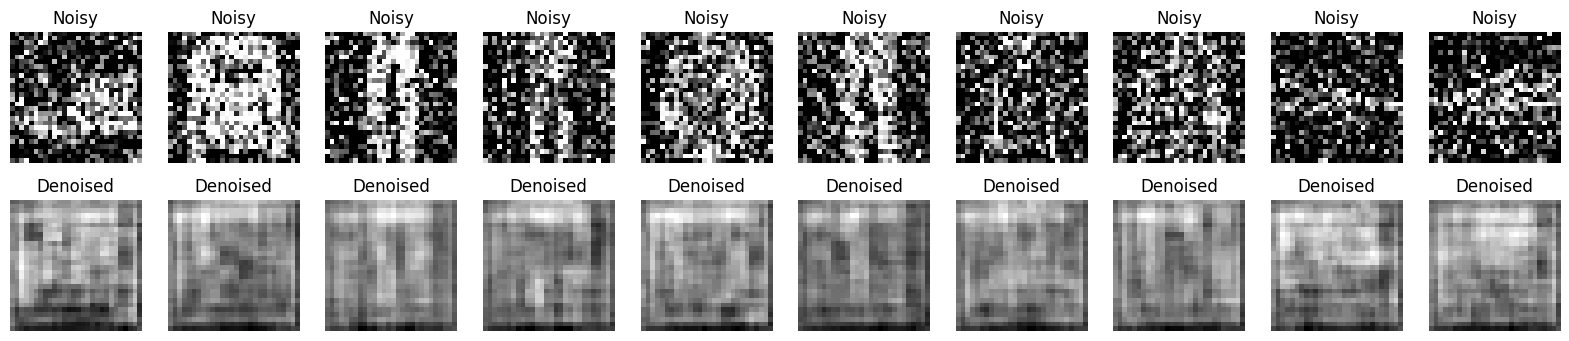

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Load Fashion MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize images to the range [0, 1]
x_test = x_test.astype('float32') / 255.

# Reshape images to (num_samples, 28, 28, 1) for convolutional autoencoder if needed
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Define a simple autoencoder model
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# You might want to train the autoencoder here, or load pre-trained weights.
# For demonstration purposes, we'll proceed without training in this single cell.
# autoencoder.fit(x_train_noisy, x_train, epochs=..., batch_size=..., ...)

# Add random noise
noise_factor = 0.5

noisy_images = x_test[:10] + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test[:10].shape
)

noisy_images = np.clip(noisy_images, 0., 1.)

# Denoise using autoencoder
denoised_images = autoencoder.predict(noisy_images)

# Display results
plt.figure(figsize=(20,4))

for i in range(10):

    # Noisy Image
    ax = plt.subplot(2,10,i+1)
    plt.imshow(noisy_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.title("Noisy")

    # Denoised Image
    ax = plt.subplot(2,10,i+11)
    plt.imshow(denoised_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.title("Denoised")

plt.show()

4.
Build a Variational Autoencoder (VAE) using Keras for the Fashion MNIST dataset. After training, sample 5 random points from the latent space and generate new images from these points.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


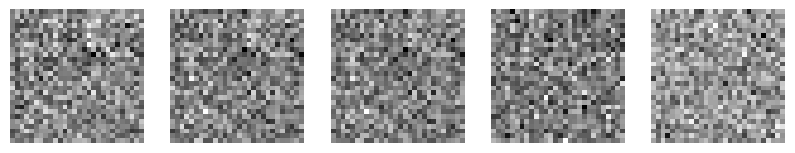

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, Model

latent_dim = 2

# Encoder
encoder_inputs = layers.Input(shape=(784,))
x = layers.Dense(256, activation="relu")(encoder_inputs)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z]
)

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(256, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(
    784,
    activation="sigmoid"
)(x)

decoder = Model(latent_inputs, decoder_outputs)

# Generate 5 random images
random_latent_vectors = np.random.normal(
    size=(5, latent_dim)
)

generated_images = decoder.predict(
    random_latent_vectors
)

plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(
        generated_images[i].reshape(28,28),
        cmap='gray'
    )
    plt.axis('off')

plt.show()

5.
Use ChatGPT to explain in your own words what KL-divergence loss does in a VAE and why it is needed. Paste your prompt and ChatGPT's response as your answer.

Prompt Used

Explain in simple words what KL-divergence loss does in a Variational Autoencoder (VAE) and why it is necessary.

ChatGPT Response

KL-divergence loss helps a Variational Autoencoder keep its latent space organized. It measures how different the learned latent distribution is from a standard normal distribution (mean 0 and variance 1). Without KL-divergence, the encoder could place data points randomly in the latent space, making it difficult to generate meaningful new samples. By encouraging the latent vectors to follow a normal distribution, KL-divergence ensures that nearby points represent similar data and allows the decoder to generate realistic new images when random latent vectors are sampled. Therefore, KL-divergence is essential for smooth interpolation and image generation in a VAE.



In My Own Words




KL-Divergence loss helps a Variational Autoencoder (VAE) organize its latent space in a meaningful way. It encourages the latent vectors to follow a standard normal distribution. This allows the VAE to generate realistic and new images from randomly sampled latent points. Without KL-Divergence loss, the latent space could become disorganized, making it difficult for the model to generate high-quality and meaningful images.